When the economy gets shaky, people don't always call their financial advisor. They open a browser tab and start typing.

Google Trends captures that impulse in real time. Unlike GDP figures or unemployment reports, which lag weeks or months behind reality, search data reflects the moment people start to feel something is wrong. Before layoffs show up in government statistics, people are already searching "how to save money" and "food bank near me."

In this post, we use Google Trends data to trace the rhythms of American economic anxiety from 2019 to the present. We look at four search terms that together tell a story about how ordinary people experience financial stress:

- **`how to save money`**: a broad signal of belt-tightening
- **`food bank near me`**: a sharper signal of acute need
- **`layoff`**: job insecurity and fear of unemployment
- **`recession`**: awareness of or anxiety about broader economic collapse

What we find is that these four terms move together in revealing ways, spiking around the same moments of national economic stress, and that the pattern of searches often precedes or amplifies what shows up in official data.


## Getting the Data

Google Trends data is freely available at [trends.google.com](https://trends.google.com). For this analysis, we downloaded weekly search interest data for each of our four terms in the United States, covering **January 2019 through March 2026**.

A few things to keep in mind about how Google Trends works:

- Values are **relative**, not absolute. A score of 100 means peak search interest for that term over the selected period. A score of 50 means half as much interest.
- You can compare multiple terms in a single download, which normalizes them against each other. We do this so the terms are on the same scale.
- When you download the CSV, the first two rows are metadata. We skip those when loading into pandas.

To get this data yourself:
1. Go to [trends.google.com](https://trends.google.com)
2. Search for `how to save money` and add the other three terms using the **+ Compare** button
3. Set the region to **United States** and the time range to **2019-01-01 to present**
4. Click the download icon to save the CSV
5. Save it as `data/economic_anxiety.csv`


## Setup

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

import warnings
warnings.filterwarnings('ignore')

# Consistent styling across all plots
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## Load and Clean the Data

In [14]:
# Skip the first two metadata rows that Google Trends adds to every CSV export
df = pd.read_csv(
    'data/economic_anxiety.csv',
    skiprows=2,
    index_col=0,
    parse_dates=True
)

# Rename columns to something readable
df.columns = ['save_money', 'food_bank', 'layoff', 'recession']

# Replace '<1' values (Google Trends uses this for very low interest) with 0
df = df.replace('<1', 0)

# Make sure values are numeric
df = df.apply(pd.to_numeric, errors='coerce')

print(f"Dataset: {df.index[0].date()} to {df.index[-1].date()}")
print(f"Rows: {len(df)}")
df.head()

Dataset: 2004-03-01 to 2026-03-01
Rows: 265


,save_money,food_bank,layoff,recession
2004-02-01,,,,
2004-03-01,1,0,5,5
2004-04-01,2,0,5,5
2004-05-01,2,0,5,4
2004-06-01,2,0,6,4
2004-07-01,2,0,6,3


## A First Look: All Four Terms Over Time

Before diving into individual terms, it helps to see them together. The chart below plots weekly search interest for all four terms from 2019 to the present. A few events are annotated to give context.

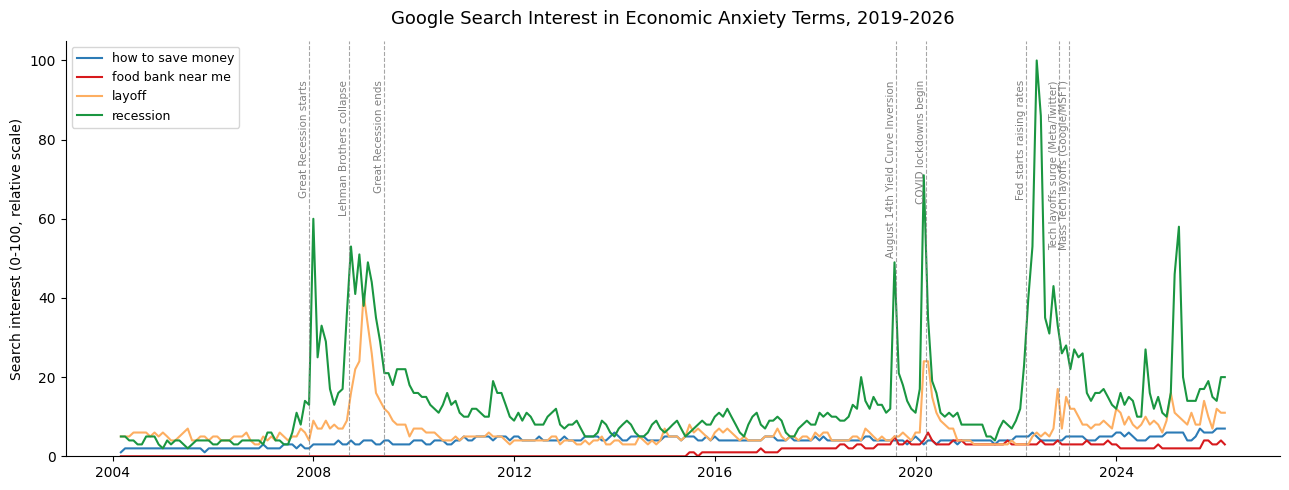

In [26]:
fig, ax = plt.subplots()

colors = {
    'save_money': '#2c7bb6',
    'food_bank':  '#d7191c',
    'layoff':     '#fdae61',
    'recession':  '#1a9641'
}

labels = {
    'save_money': 'how to save money',
    'food_bank':  'food bank near me',
    'layoff':     'layoff',
    'recession':  'recession'
}

for col in df.columns:
    ax.plot(df.index, df[col], label=labels[col], color=colors[col], linewidth=1.5)

# Annotate key economic moments
annotations = [
    ('2007-12-01', 'Great Recession starts'),
    ('2008-09-15', 'Lehman Brothers collapse'),
    ('2009-06-01', 'Great Recession ends'),
    ('2019-08-14', 'August 14th Yield Curve Inversion'),
    ('2020-03-15', 'COVID lockdowns begin'),
    ('2022-03-16', 'Fed starts raising rates'),
    ('2022-11-09', 'Tech layoffs surge (Meta/Twitter)'),
    ('2023-01-20', 'Mass Tech layoffs (Google/MSFT)'),
]
for date_str, label in annotations:
    ax.axvline(pd.Timestamp(date_str), color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.text(pd.Timestamp(date_str), 95, label, rotation=90, fontsize=7.5,
            va='top', ha='right', color='gray')

ax.set_title('Google Search Interest in Economic Anxiety Terms, 2004-2026', fontsize=13, pad=12)
ax.set_ylabel('Search interest (0-100, relative scale)')
ax.set_xlabel('')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('figures/all_terms_overview.png', dpi=150)
plt.show()

## The Great Recession: 2008



## The COVID Spike: March 2020

The most dramatic feature in the data is what happens in March 2020. When the pandemic hit and lockdowns began, all four terms spiked simultaneously.

"Food bank near me" reached its highest point in the entire dataset in the weeks following lockdown. This makes sense: millions of people were suddenly out of work, many of them hourly workers in food service and retail who had little savings buffer. For many Americans, the search bar was the first place they turned.

"Layoff" and "recession" both surged too, but they peaked slightly later, as the economic fallout became clearer. "How to save money" spiked early and stayed elevated for longer, suggesting that the belt-tightening instinct outlasted the acute crisis.

Let's zoom in on that period to see the timing more clearly.

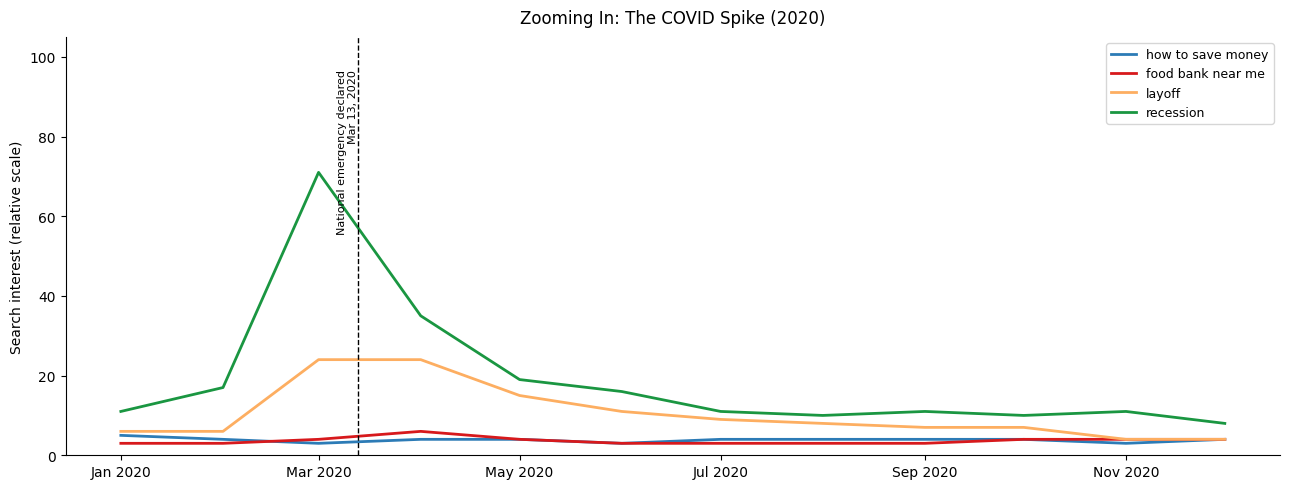

In [16]:
# Focus on January 2020 to December 2020
covid_window = df['2020-01-01':'2020-12-31']

fig, ax = plt.subplots()

for col in covid_window.columns:
    ax.plot(covid_window.index, covid_window[col], label=labels[col], color=colors[col], linewidth=2)

ax.axvline(pd.Timestamp('2020-03-13'), color='black', linestyle='--', linewidth=1)
ax.text(pd.Timestamp('2020-03-13'), 97, 'National emergency declared\nMar 13, 2020',
        rotation=90, fontsize=8, va='top', ha='right')

ax.set_title('Zooming In: The COVID Spike (2020)', fontsize=12, pad=10)
ax.set_ylabel('Search interest (relative scale)')
ax.legend(loc='upper right', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('figures/covid_zoom.png', dpi=150)
plt.show()

## The Slow Burn: Inflation and Tech Layoffs, 2022-2023

After 2020, the data quiets down, but it does not go flat. A second, less dramatic wave of anxiety emerges starting in mid-2022, driven by a very different set of forces: inflation reaching 40-year highs and a wave of tech sector layoffs.

This wave looks different from the COVID spike. Instead of a sharp, synchronized jump across all four terms, the 2022 pattern is more gradual and term-specific. "Recession" climbs steadily through 2022 as economists debate whether the Fed's rate hikes will cause a downturn. "Layoff" spikes in late 2022 and early 2023, tracking the wave of cuts at major tech companies.

"Food bank near me" also ticks up in 2022, likely reflecting the squeeze of high grocery and energy prices on lower-income households. This is a quieter story than March 2020, but in some ways a more persistent one.

Below we look at just 2022-2023 to see this pattern more clearly.

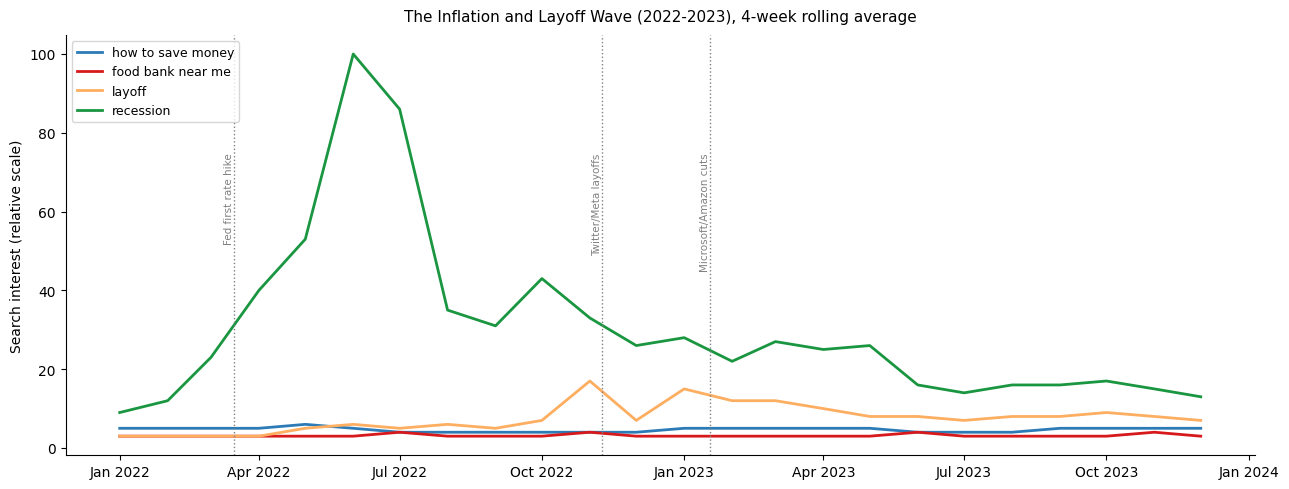

In [17]:
inflation_window = df['2022-01-01':'2023-12-31']

fig, ax = plt.subplots()

for col in inflation_window.columns:
    # Apply a 4-week rolling average to smooth out noise
    smoothed = inflation_window[col].rolling('28D').mean()
    ax.plot(smoothed.index, smoothed, label=labels[col], color=colors[col], linewidth=2)

# Annotate key events
events_2022 = [
    ('2022-03-16', 'Fed first rate hike'),
    ('2022-11-09', 'Twitter/Meta layoffs'),
    ('2023-01-18', 'Microsoft/Amazon cuts'),
]
for date_str, label in events_2022:
    ax.axvline(pd.Timestamp(date_str), color='gray', linestyle=':', linewidth=1)
    ax.text(pd.Timestamp(date_str), 75, label, rotation=90, fontsize=7.5,
            va='top', ha='right', color='gray')

ax.set_title('The Inflation and Layoff Wave (2022-2023), 4-week rolling average', fontsize=11, pad=10)
ax.set_ylabel('Search interest (relative scale)')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('figures/inflation_wave.png', dpi=150)
plt.show()

## Comparing the Two Waves

To make the contrast between 2020 and 2022 concrete, we can compute the average search interest for each term across two windows: the COVID shock (March to June 2020) and the inflation period (July 2022 to December 2022).

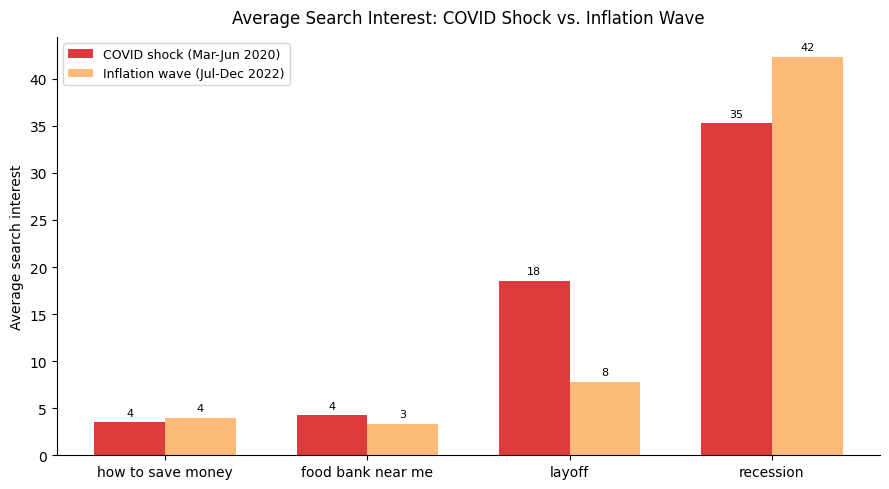

            COVID shock (Mar-Jun 2020)  Inflation wave (Jul-Dec 2022)
save_money                         3.5                            4.0
food_bank                          4.2                            3.3
layoff                            18.5                            7.8
recession                         35.2                           42.3


In [18]:
covid_avg = df['2020-03-01':'2020-06-30'].mean()
inflation_avg = df['2022-07-01':'2022-12-31'].mean()

comparison = pd.DataFrame({
    'COVID shock (Mar-Jun 2020)': covid_avg,
    'Inflation wave (Jul-Dec 2022)': inflation_avg
})

fig, ax = plt.subplots(figsize=(9, 5))

x = range(len(comparison))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], comparison['COVID shock (Mar-Jun 2020)'],
               width=width, label='COVID shock (Mar-Jun 2020)', color='#d7191c', alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], comparison['Inflation wave (Jul-Dec 2022)'],
               width=width, label='Inflation wave (Jul-Dec 2022)', color='#fdae61', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels([labels[c] for c in comparison.index], fontsize=10)
ax.set_ylabel('Average search interest')
ax.set_title('Average Search Interest: COVID Shock vs. Inflation Wave', fontsize=12, pad=10)
ax.legend(fontsize=9)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('figures/wave_comparison.png', dpi=150)
plt.show()

print(comparison.round(1))

## Where in America? Regional Breakdown

Google Trends also lets you see which states show the highest interest in a given term, relative to all searches from that state. This geographic layer adds texture to the story.

For example: interest in "food bank near me" tends to be higher in states with weaker social safety nets and higher poverty rates. Interest in "layoff" tracks more closely with states that have large tech or manufacturing workforces.

To get state-level data:
1. On Google Trends, run the same search
2. Scroll down to the **"Interest by subregion"** section
3. Download that CSV separately (it gives you one row per state)

The cell below loads and displays that data if you have it. Otherwise, it skips gracefully.

In [22]:
regional_path = 'data/economic_anxiety_by_state.csv'

if os.path.exists(regional_path):
    # Load the data
    state_df = pd.read_csv(regional_path, skiprows=2, index_col=0)
    state_df.columns = ['save_money', 'food_bank', 'layoff', 'recession']
    
    # 1. Replace '<1' with '0'
    # 2. Remove the '%' character so '24%' becomes '24'
    # 3. Convert to numeric
    state_df = state_df.replace('<1', '0')
    state_df = state_df.replace(r'%', '', regex=True).apply(pd.to_numeric)
    
    print("Top 10 states by 'food bank near me' search interest:")
    print(state_df['food_bank'].sort_values(ascending=False).head(10))
else:
    print("File not found.")

Top 10 states by 'food bank near me' search interest:
Region
Arizona           14
Washington        13
Delaware          11
Utah              10
Idaho              9
Louisiana          9
Alaska             9
Colorado           8
Nevada             8
South Carolina     8
Name: food_bank, dtype: int64


## What the Search Bar Tells Us

The patterns in this data reinforce something that economists and journalists have increasingly come to appreciate: search behavior is a sensitive, real-time instrument for measuring public sentiment.

A few things stand out from this analysis:

**1. The COVID shock was uniquely broad.** All four terms moved together in March 2020 in a way that had no precedent in the prior year. The speed and synchrony of the spike reflects how sudden and universal that economic disruption was.

**2. The inflation wave was slower and more differentiated.** In 2022, "recession" and "layoff" climbed while "food bank" and "save money" rose more modestly. This reflects a more uneven distribution of stress: the inflation era hit some households much harder than others depending on income, employment sector, and housing situation.

**3. Search data can be a leading indicator.** In both cases, search interest started climbing before official economic data confirmed the scale of the problem. This is the core appeal of using Google Trends for social research: it captures anxiety in real time, before it shows up in surveys or statistics.

Of course, search data has real limits. It reflects who has internet access and who uses Google. It captures the act of searching, not the underlying need. Someone who knows their local food bank without needing to search for it will not appear in this data. The signal is real, but it is partial.

Still, as a window into how ordinary Americans process economic uncertainty, the search bar is hard to beat.

---

*Data: Google Trends (trends.google.com), United States, weekly, 2019-2026. All search interest values are on a relative scale where 100 represents peak interest for the term over the selected period.*